
# Contour-Based Dataset Generation and Fourier Feature Extraction

This notebook builds a machine learning dataset from contour annotations of biological structures.

The workflow is:

1. Load and clean the original contour dataset.
2. Convert contour coordinates into contour arrays.
3. Detect biologically meaningful pivot points (stem neighbors and high-curvature points).
4. Generate augmented training samples centered on those pivot points.
5. Normalize contours through translation and rotation.
6. Convert contours into Fourier descriptors.
7. Build a feature matrix for machine learning.
8. Train and evaluate a baseline classifier.



## Load and Prepare the Original Dataset

The raw dataset contains contour coordinates stored as separate `x` and `y` columns.
This step:

- Loads the CSV file.
- Retains only the columns required for contour processing.
- Organizes the contour point coordinates into a consistent format.
- Prepares the data for downstream geometric analysis.


In [1]:
import numpy as np
import pandas as pd


def load_original_dataset(csv_path):
    df = pd.read_csv(csv_path)

    keep_cols = ["filename", "stem_id_ann"]

    n_points = 200

    for i in range(n_points):
        keep_cols.append(f"x{i}")
        keep_cols.append(f"y{i}")

    df = df[keep_cols].copy()

    return df


def row_to_contour(row, n_points=200):
    contour = np.array([
        [row[f"x{i}"], row[f"y{i}"]]
        for i in range(n_points)
    ], dtype=float)

    return contour

In [2]:
# =====================================================
# CALL FUNCTIONS + BUILD CLEAN DATAFRAME
# =====================================================

csv_path = "/mnt/data/users/jsoto/deliverable/original_contours_prepared_data.csv"

# Load cleaned subset of original dataset
df_clean = load_original_dataset(csv_path)

print(df_clean.head())

print("\nShape:")
print(df_clean.shape)

                                       filename  stem_id_ann        x0  \
0   in6_dorsal_yellow_area1_cover_scale0021.jpg            0  0.039616   
1   in9_dorsal_yellow_area1_cover_scale0012.jpg            0  0.045012   
2  in11_dorsal_yellow_area1_cover_scale0003.jpg          185  0.068797   
3  in6_ventral_yellow_area1_cover_scale0020.jpg            1  0.020243   
4  in9_ventral_yellow_area1_cover_scale0012.jpg            0  0.017305   

         y0        x1        y1        x2        y2        x3        y3  ...  \
0  0.075408  0.040345  0.074831  0.040981  0.074148  0.041569  0.073428  ...   
1  0.010306  0.044434  0.010863  0.044245  0.011673  0.044293  0.012507  ...   
2  0.040651  0.068278  0.041420  0.067554  0.041976  0.066705  0.042350  ...   
3  0.018986  0.020394  0.019795  0.021132  0.020471  0.021817  0.021195  ...   
4  0.041911  0.017699  0.042544  0.018433  0.042870  0.019171  0.043190  ...   

       x195      y195      x196      y196      x197      y197      x198  \


## Convert Coordinate Columns into Contour Arrays

Machine learning and geometric operations are easier when each contour is represented
as a single `(N, 2)` array of coordinates.

This step combines the individual coordinate columns into a contour object that can be
passed directly to curvature analysis, visualization, and feature extraction routines.


In [3]:
# =====================================================
# CREATE CONTOUR ARRAY COLUMN
# =====================================================

df_clean["contour"] = df_clean.apply(
    lambda row: row_to_contour(row, n_points=200),
    axis=1
)

print(df_clean[["filename", "stem_id_ann", "contour"]].head())

print("\nExample contour shape:")
print(df_clean["contour"].iloc[0].shape)

                                       filename  stem_id_ann  \
0   in6_dorsal_yellow_area1_cover_scale0021.jpg            0   
1   in9_dorsal_yellow_area1_cover_scale0012.jpg            0   
2  in11_dorsal_yellow_area1_cover_scale0003.jpg          185   
3  in6_ventral_yellow_area1_cover_scale0020.jpg            1   
4  in9_ventral_yellow_area1_cover_scale0012.jpg            0   

                                             contour  
0  [[0.0396162947313223, 0.0754077425928047], [0....  
1  [[0.0450119740894695, 0.0103055146472182], [0....  
2  [[0.0687970847281269, 0.0406514342708785], [0....  
3  [[0.0202426526169234, 0.0189860242940435], [0....  
4  [[0.0173048979512682, 0.041910653354466], [0.0...  

Example contour shape:
(200, 2)


### Finding points of high curvature and stem neighbors


## Identify Candidate Landmark Points

Not all contour points are equally informative.

The following functions identify high-curvature locations that may correspond to
important geometric features. Additional constraints are used to avoid selecting
points that are too close together or too close to the annotated stem location.


In [4]:
def circular_distance(i, j, n):
    d = abs(i - j)
    return min(d, n - d)


def find_top_outward_curvature_points(
    contour,
    stem_id_ann,
    n_points=3,
    min_distance=10,
    min_stem_distance=5,
    prominence=None
):
    """
    Select outward high-curvature points while:

    1. Enforcing circular minimum spacing between peaks
    2. Enforcing minimum distance from stem_id_ann
    """

    outward_curvature = get_outward_curvature(contour)

    peaks, _ = find_peaks(
        outward_curvature,
        prominence=prominence
    )

    if len(peaks) == 0:
        return [], outward_curvature

    # Sort peaks by curvature strength descending
    sorted_peaks = peaks[
        np.argsort(outward_curvature[peaks])[::-1]
    ]

    selected = []

    for candidate in sorted_peaks:

        # --------------------------------------------
        # Distance from annotated stem
        # --------------------------------------------

        stem_dist = circular_distance(
            candidate,
            stem_id_ann,
            len(contour)
        )

        if stem_dist < min_stem_distance:
            continue

        # --------------------------------------------
        # Distance from already selected peaks
        # --------------------------------------------

        too_close = False

        for existing in selected:

            d = circular_distance(
                candidate,
                existing,
                len(contour)
            )

            if d < min_distance:
                too_close = True
                break

        if too_close:
            continue

        selected.append(candidate)

        if len(selected) >= n_points:
            break

    return selected, outward_curvature

In [5]:
import numpy as np
from scipy.signal import find_peaks


def polygon_signed_area(contour):
    x = contour[:, 0]
    y = contour[:, 1]

    return 0.5 * np.sum(
        x * np.roll(y, -1) - y * np.roll(x, -1)
    )


def compute_signed_curvature(contour):
    prev_pts = np.roll(contour, 1, axis=0)
    next_pts = np.roll(contour, -1, axis=0)

    d1 = next_pts - prev_pts
    d2 = next_pts - 2 * contour + prev_pts

    dx = d1[:, 0]
    dy = d1[:, 1]
    ddx = d2[:, 0]
    ddy = d2[:, 1]

    numerator = dx * ddy - dy * ddx
    denominator = (dx**2 + dy**2) ** 1.5

    curvature = numerator / (denominator + 1e-8)

    return curvature


def get_outward_curvature(contour):
    curvature = compute_signed_curvature(contour)
    area = polygon_signed_area(contour)

    if area > 0:
        outward_curvature = -curvature
    else:
        outward_curvature = curvature

    return outward_curvature


def circular_distance(i, j, n):
    d = abs(int(i) - int(j))
    return min(d, n - d)


def find_top_outward_curvature_points(
    contour,
    stem_id_ann,
    n_points=3,
    min_distance=10,
    min_stem_distance=5,
    prominence=None
):
    outward_curvature = get_outward_curvature(contour)

    # For convex points, detect peaks in the negative outward curvature.
    # This selects the strongest outward bends instead of inward/concave bends.
    peaks, _ = find_peaks(
        -outward_curvature,
        prominence=prominence
    )

    if len(peaks) == 0:
        return [], outward_curvature

    # Sort from most convex to least convex.
    # More negative outward curvature indicates stronger convexity.
    sorted_peaks = peaks[
        np.argsort(outward_curvature[peaks])
    ]

    selected = []

    for candidate in sorted_peaks:
        stem_dist = circular_distance(
            candidate,
            stem_id_ann,
            len(contour)
        )

        if stem_dist < min_stem_distance:
            continue

        too_close = False

        for existing in selected:
            d = circular_distance(
                candidate,
                existing,
                len(contour)
            )

            if d < min_distance:
                too_close = True
                break

        if too_close:
            continue

        selected.append(int(candidate))

        if len(selected) >= n_points:
            break

    return selected, outward_curvature


## Compute High-Curvature Features for Each Contour

For every contour, the curvature analysis routine is executed and the most prominent
outward-facing curvature points are stored. These points will later become candidate
pivot locations for generating training examples.


In [6]:
df_features = df_clean.copy()

df_features["high_curvature_ids"] = df_features.apply(
    lambda row: find_top_outward_curvature_points(
        contour=row["contour"],
        stem_id_ann=row["stem_id_ann"],
        n_points=3,
        min_distance=10,
        min_stem_distance=5
    )[0],
    axis=1
)

df_features[
    ["filename", "stem_id_ann", "high_curvature_ids"]
].head()

,filename,stem_id_ann,high_curvature_ids
0,in6_dorsal_yellow_area1_cover_scale0021.jpg,0,"[12, 95, 182]"
1,in9_dorsal_yellow_area1_cover_scale0012.jpg,0,"[98, 86, 112]"
2,in11_dorsal_yellow_area1_cover_scale0003.jpg,185,"[166, 87, 10]"
3,in6_ventral_yellow_area1_cover_scale0020.jpg,1,"[112, 92, 15]"
4,in9_ventral_yellow_area1_cover_scale0012.jpg,0,"[98, 84, 13]"



## Define Stem Neighbor Points

The stem annotation itself may not fully capture the local geometry.

To provide additional training examples, the immediate neighbors of the stem point
(previous and next contour indices) are identified using circular indexing.


In [7]:
def get_stem_neighbor_triplet(stem_id, n_points=200):
    """
    Returns:
    [previous_point, stem_point, next_point]

    Circular indexing is used, so:
    stem_id = 0 -> [199, 0, 1]
    """

    prev_id = (stem_id - 1) % n_points
    next_id = (stem_id + 1) % n_points

    return [prev_id, stem_id, next_id]


## Assemble the Feature-Enriched Contour Dataset

This step combines:

- Original contour information
- Annotated stem locations
- Stem-neighbor points
- High-curvature landmark points

The resulting dataframe contains all geometric information required to generate the
final classification dataset.


In [8]:
# Start once from clean dataframe
df_features = df_clean.copy()

# 1. Add high curvature points
df_features["high_curvature_ids"] = df_features.apply(
    lambda row: find_top_outward_curvature_points(
        contour=row["contour"],
        stem_id_ann=row["stem_id_ann"],
        n_points=3,
        min_distance=10,
        min_stem_distance=5
    )[0],
    axis=1
)

# 2. Add stem neighbor points
df_features["stem_neighbor_ids"] = df_features["stem_id_ann"].apply(
    lambda stem_id: get_stem_neighbor_triplet(
        stem_id,
        n_points=200
    )
)

# 3. Inspect both columns
df_features[
    [
        "filename",
        "stem_id_ann",
        "high_curvature_ids",
        "stem_neighbor_ids"
    ]
].head()

,filename,stem_id_ann,high_curvature_ids,stem_neighbor_ids
0,in6_dorsal_yellow_area1_cover_scale0021.jpg,0,"[12, 95, 182]","[199, 0, 1]"
1,in9_dorsal_yellow_area1_cover_scale0012.jpg,0,"[98, 86, 112]","[199, 0, 1]"
2,in11_dorsal_yellow_area1_cover_scale0003.jpg,185,"[166, 87, 10]","[184, 185, 186]"
3,in6_ventral_yellow_area1_cover_scale0020.jpg,1,"[112, 92, 15]","[0, 1, 2]"
4,in9_ventral_yellow_area1_cover_scale0012.jpg,0,"[98, 84, 13]","[199, 0, 1]"


### Creating new training data set with stem neighbors and high curvature points


## Normalize Contours Relative to a Pivot Point

Each training sample is created relative to a selected pivot point.

To make the representation invariant to position and orientation:

1. The contour is rolled so the pivot becomes index 0.
2. The pivot is translated to the origin.
3. The contour is rotated into a canonical orientation.

This reduces irrelevant variation and helps the classifier focus on shape.


In [9]:
def recenter_and_rotate_contour(contour, pivot_id, target_angle=-np.pi / 2):
    """
    1. Roll contour so pivot_id becomes index 0
    2. Translate pivot to (0,0)
    3. Rotate contour so pivot-to-centroid direction points to target_angle

    target_angle = -pi/2 means the shape centroid points downward from pivot.
    """

    pivot_id = int(pivot_id)

    pivot_point = contour[pivot_id].copy()

    # Roll so pivot becomes first point
    rolled = np.roll(contour, -pivot_id, axis=0)

    # Translate so pivot is origin
    translated = rolled - pivot_point

    # Compute centroid after translation
    centroid = translated.mean(axis=0)

    # Current angle from pivot/origin to centroid
    current_angle = np.arctan2(centroid[1], centroid[0])

    # Rotation needed
    rotation_angle = target_angle - current_angle

    cos_a = np.cos(rotation_angle)
    sin_a = np.sin(rotation_angle)

    R = np.array([
        [cos_a, -sin_a],
        [sin_a,  cos_a]
    ])

    rotated = translated @ R.T

    return rotated


def generate_training_samples(df):
    rows = []

    for _, row in df.iterrows():

        contour = row["contour"]
        filename = row["filename"]

        # Positive examples
        for pivot_id in row["stem_neighbor_ids"]:

            rc = recenter_and_rotate_contour(
                contour,
                pivot_id
            )

            rows.append({
                "filename": filename,
                "pivot_id": pivot_id,
                "pivot_type": "stem_neighbor",
                "label": 1,
                "contour": rc
            })

        # Negative examples
        for pivot_id in row["high_curvature_ids"]:

            rc = recenter_and_rotate_contour(
                contour,
                pivot_id
            )

            rows.append({
                "filename": filename,
                "pivot_id": pivot_id,
                "pivot_type": "curvature_peak",
                "label": 0,
                "contour": rc
            })

    return pd.DataFrame(rows)


## Generate Training Samples

Training samples are produced from both stem-neighbor and high-curvature pivots.

Each generated sample contains:

- The transformed contour
- Pivot metadata
- The class label describing the pivot type

This converts each original contour into multiple supervised learning examples.


In [10]:
df_training = generate_training_samples(df_features)

print(df_training.head())

print("\nShape:")
print(df_training.shape)

                                      filename  pivot_id      pivot_type  \
0  in6_dorsal_yellow_area1_cover_scale0021.jpg       199   stem_neighbor   
1  in6_dorsal_yellow_area1_cover_scale0021.jpg         0   stem_neighbor   
2  in6_dorsal_yellow_area1_cover_scale0021.jpg         1   stem_neighbor   
3  in6_dorsal_yellow_area1_cover_scale0021.jpg        12  curvature_peak   
4  in6_dorsal_yellow_area1_cover_scale0021.jpg        95  curvature_peak   

   label                                            contour  
0      1  [[0.0, 0.0], [0.0, 0.0], [0.000523992227499918...  
1      1  [[0.0, 0.0], [0.0005239922274999185, -0.000767...  
2      1  [[0.0, 0.0], [0.00041676986792604754, -0.00083...  
3      0  [[0.0, 0.0], [0.0008106933604945264, 0.0003691...  
4      0  [[0.0, 0.0], [0.000854307769921253, -0.0002928...  

Shape:
(1332, 5)


In [11]:
df_training.to_csv("visualize_training.csv")
print(df_training.head(12))


                                       filename  pivot_id      pivot_type  \
0   in6_dorsal_yellow_area1_cover_scale0021.jpg       199   stem_neighbor   
1   in6_dorsal_yellow_area1_cover_scale0021.jpg         0   stem_neighbor   
2   in6_dorsal_yellow_area1_cover_scale0021.jpg         1   stem_neighbor   
3   in6_dorsal_yellow_area1_cover_scale0021.jpg        12  curvature_peak   
4   in6_dorsal_yellow_area1_cover_scale0021.jpg        95  curvature_peak   
5   in6_dorsal_yellow_area1_cover_scale0021.jpg       182  curvature_peak   
6   in9_dorsal_yellow_area1_cover_scale0012.jpg       199   stem_neighbor   
7   in9_dorsal_yellow_area1_cover_scale0012.jpg         0   stem_neighbor   
8   in9_dorsal_yellow_area1_cover_scale0012.jpg         1   stem_neighbor   
9   in9_dorsal_yellow_area1_cover_scale0012.jpg        98  curvature_peak   
10  in9_dorsal_yellow_area1_cover_scale0012.jpg        86  curvature_peak   
11  in9_dorsal_yellow_area1_cover_scale0012.jpg       112  curvature_peak   


## Visual Validation of Generated Samples

Before training a model, it is useful to visually inspect transformed contours.

The following plots verify that:
- Pivot alignment is correct.
- Rotation normalization behaves as expected.
- Labels correspond to the intended contour locations.


filename: in6_dorsal_yellow_area1_cover_scale0021.jpg
pivot_id: 182
Original pivot coordinate:
[0.03053156 0.07156083]

Recentered first point:
[0. 0.]

Should be close to [0, 0]:
True

Original point 0:
[0.03961629 0.07540774]

Recentered point 0:
[0. 0.]


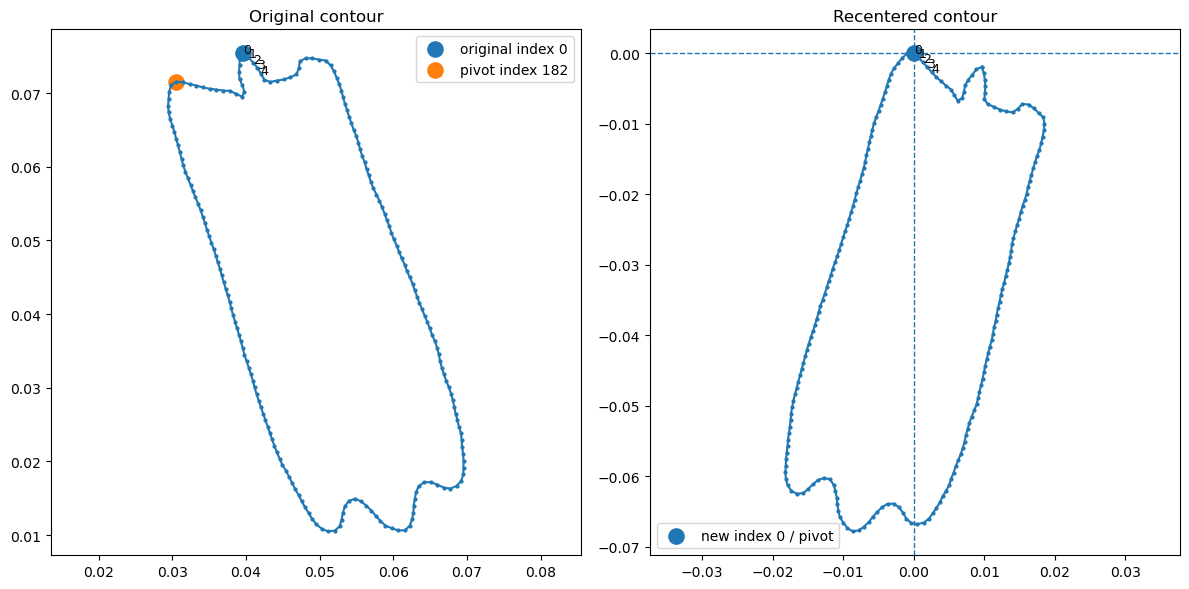

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Pick training sample
sample_idx = 5
sample = df_training.iloc[sample_idx]

filename = sample["filename"]
pivot_id = int(sample["pivot_id"])

# Get matching original row
original_row = df_features.loc[
    df_features["filename"] == filename
].iloc[0]

original_contour = original_row["contour"]
recentered_contour = sample["contour"]

print("filename:", filename)
print("pivot_id:", pivot_id)
print("Original pivot coordinate:")
print(original_contour[pivot_id])

print("\nRecentered first point:")
print(recentered_contour[0])

print("\nShould be close to [0, 0]:")
print(np.allclose(recentered_contour[0], [0, 0]))

print("\nOriginal point 0:")
print(original_contour[0])

print("\nRecentered point 0:")
print(recentered_contour[0])


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# -----------------------------
# Original contour
# -----------------------------
axes[0].plot(
    original_contour[:, 0],
    original_contour[:, 1],
    marker="o",
    markersize=2
)

axes[0].scatter(
    original_contour[0, 0],
    original_contour[0, 1],
    s=120,
    label="original index 0"
)

axes[0].scatter(
    original_contour[pivot_id, 0],
    original_contour[pivot_id, 1],
    s=120,
    label=f"pivot index {pivot_id}"
)

# Mark first 5 original points
for i in range(5):
    axes[0].text(
        original_contour[i, 0],
        original_contour[i, 1],
        str(i),
        fontsize=9
    )

axes[0].set_title("Original contour")
axes[0].axis("equal")
axes[0].legend()


# -----------------------------
# Recentered contour
# -----------------------------
axes[1].plot(
    recentered_contour[:, 0],
    recentered_contour[:, 1],
    marker="o",
    markersize=2
)

axes[1].scatter(
    recentered_contour[0, 0],
    recentered_contour[0, 1],
    s=120,
    label="new index 0 / pivot"
)

# Mark first 5 recentered points
for i in range(5):
    axes[1].text(
        recentered_contour[i, 0],
        recentered_contour[i, 1],
        str(i),
        fontsize=9
    )

# Add origin lines
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].axvline(0, linestyle="--", linewidth=1)

axes[1].set_title("Recentered contour")
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()

Filename: in6_dorsal_yellow_area1_cover_scale0021.jpg
Number of generated samples: 6


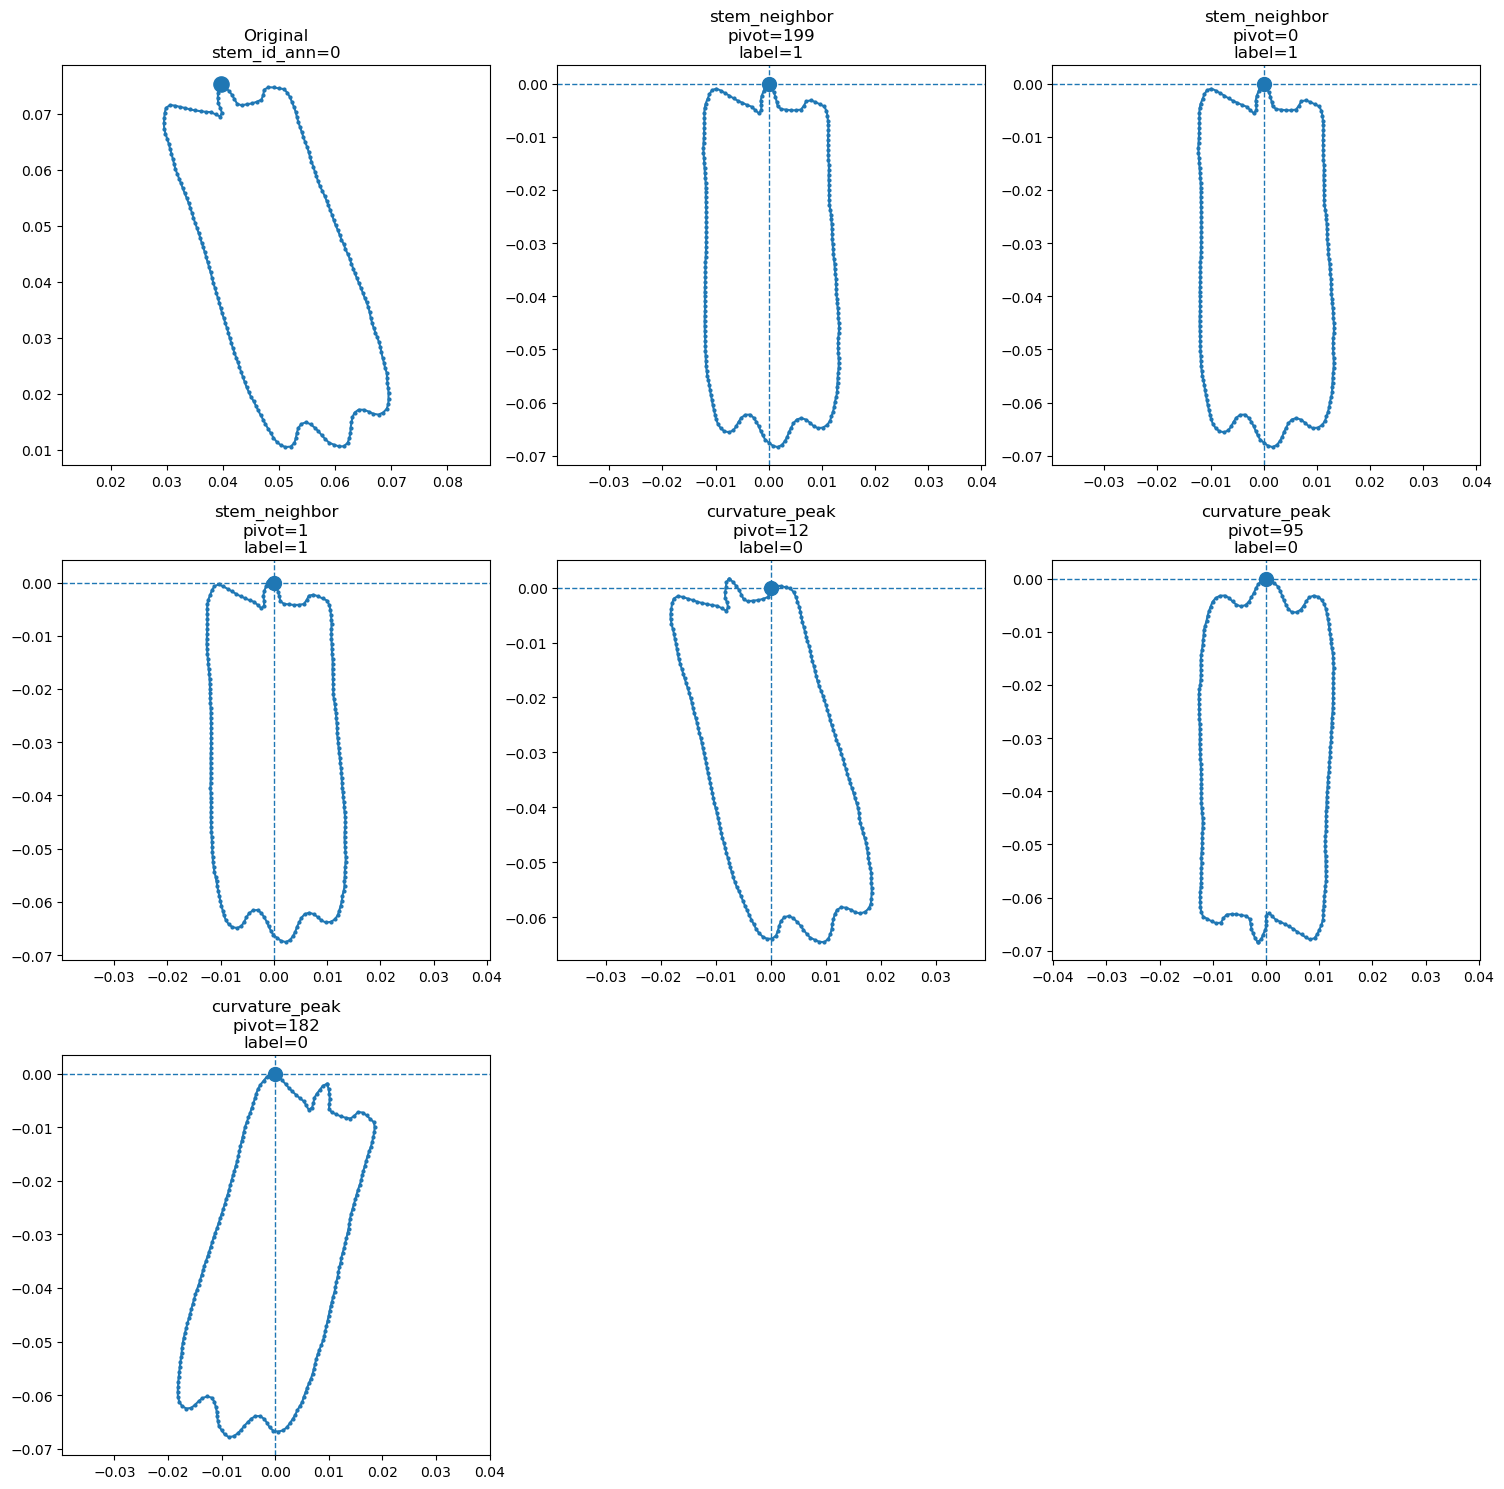

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# SELECT FILENAME TO VISUALIZE
# =====================================================

sample_idx = 5

filename = df_training.iloc[sample_idx]["filename"]

# Original contour
original_row = df_features[
    df_features["filename"] == filename
].iloc[0]

original_contour = original_row["contour"]

# All generated samples for this filename
samples = df_training[
    df_training["filename"] == filename
].reset_index(drop=True)

print("Filename:", filename)
print("Number of generated samples:", len(samples))

# =====================================================
# CREATE GRID
# =====================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 15)
)

axes = axes.flatten()

# =====================================================
# PANEL 0: ORIGINAL CONTOUR
# =====================================================

axes[0].plot(
    original_contour[:, 0],
    original_contour[:, 1],
    marker="o",
    markersize=2
)

stem_id = int(original_row["stem_id_ann"])

axes[0].scatter(
    original_contour[stem_id, 0],
    original_contour[stem_id, 1],
    s=120
)

axes[0].set_title(
    f"Original\nstem_id_ann={stem_id}"
)

axes[0].axis("equal")

# =====================================================
# PANELS 1-6: GENERATED SAMPLES
# =====================================================

for i, (_, sample) in enumerate(samples.iterrows()):

    ax = axes[i + 1]

    contour = sample["contour"]

    pivot_id = int(sample["pivot_id"])

    label = sample["label"]

    pivot_type = sample["pivot_type"]

    ax.plot(
        contour[:, 0],
        contour[:, 1],
        marker="o",
        markersize=2
    )

    # Pivot should be origin
    ax.scatter(
        0,
        0,
        s=100
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"{pivot_type}\n"
        f"pivot={pivot_id}\n"
        f"label={label}"
    )

    ax.axis("equal")

# =====================================================
# HIDE UNUSED PANELS
# =====================================================

for j in range(len(samples) + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Moving from contour points to fourier transforms

### Step 1: Convert contour into a signal

combining: (x,y). 
into: x + iy

Turning our 2D points into a 1D signal

### Step 2: Apply the Fourier Transform

Instead of remembering 200 points, we represent the contour as a combination of shape frequencies.  

### Step 3: Normalize

scaling all contours to a similar size.  

### Step 4: Keep only the first N coefficients

The first coefficients contain most of the shape information.

### Step 5: Separate real and imaginary parts

convert: 3 + 4i  
into: 

3
4   
 
unpacking the Fourier descriptors into ordinary numbers, so we can use sklearn models (require real-valued features)



## Fourier Descriptor Extraction

Rather than feeding all contour coordinates directly into a machine learning model,
the contour is compressed using Fourier descriptors.

Benefits include:

- Lower dimensionality
- Improved rotational and translational robustness
- Compact representation of overall shape

Only the lowest-frequency coefficients are retained because they capture the most
important shape information.


In [14]:
import numpy as np


def contour_to_fourier(contour, n_coeffs=20):
    """
    Convert a contour into Fourier descriptor features.

    Parameters
    ----------
    contour : ndarray
        Shape (200,2)

    n_coeffs : int
        Number of low-frequency coefficients to keep

    Returns
    -------
    features : ndarray
        Shape (2*n_coeffs,)
    """

    # Convert contour to complex signal
    z = contour[:, 0] + 1j * contour[:, 1]

    # FFT
    coeffs = np.fft.fft(z)

    # ----------------------------------
    # Optional scale normalization
    # ----------------------------------

    if np.abs(coeffs[1]) > 1e-10:
        coeffs = coeffs / np.abs(coeffs[1])

    # Keep low-frequency coefficients
    coeffs = coeffs[:n_coeffs]

    # Convert complex values into real features
    features = np.concatenate([
        coeffs.real,
        coeffs.imag
    ])

    return features

### Step 6: Build the feature matrix

converting shapes into rows of numbers.

In [15]:
N_COEFFS = 20

X_fourier = np.vstack(
    df_training["contour"].apply(
        lambda c: contour_to_fourier(
            c,
            n_coeffs=N_COEFFS
        )
    )
)

y = df_training["label"].values

print("X shape:", X_fourier.shape)
print("y shape:", y.shape)

X shape: (1332, 40)
y shape: (1332,)



## Create a Machine-Learning Ready DataFrame

The Fourier coefficients are expanded into explicit feature columns.

Each row now represents a contour sample and each column represents a numerical
shape descriptor suitable for traditional machine learning algorithms.


In [16]:
feature_names = []

for i in range(N_COEFFS):
    feature_names.append(f"fd_real_{i}")

for i in range(N_COEFFS):
    feature_names.append(f"fd_imag_{i}")

df_fourier = pd.DataFrame(
    X_fourier,
    columns=feature_names
)

df_fourier["label"] = y

df_fourier["filename"] = df_training["filename"].values

df_fourier.head()

,fd_real_0,fd_real_1,fd_real_2,fd_real_3,fd_real_4,fd_real_5,fd_real_6,fd_real_7,fd_real_8,fd_real_9,...,fd_imag_12,fd_imag_13,fd_imag_14,fd_imag_15,fd_imag_16,fd_imag_17,fd_imag_18,fd_imag_19,label,filename
0,7.090568e-16,-0.122410,-0.018291,0.021369,-0.000510,0.015296,0.003128,-0.003614,0.014499,-0.018035,...,0.015278,0.021276,0.008484,0.007652,0.005055,0.002497,0.002682,0.002560,1,in6_dorsal_yellow_area1_cover_scale0021.jpg
1,7.090568e-16,-0.153524,-0.017411,0.032530,0.001938,0.021572,0.000663,-0.007889,0.008440,-0.028819,...,0.021296,0.012141,0.013877,0.003019,0.008183,0.002445,0.002789,0.005063,1,in6_dorsal_yellow_area1_cover_scale0021.jpg
2,-9.213132e-17,-0.200351,-0.016208,0.045231,0.004663,0.027872,-0.002038,-0.012050,0.001418,-0.037716,...,0.024378,0.000553,0.016672,-0.002452,0.009285,0.001681,0.001996,0.005807,1,in6_dorsal_yellow_area1_cover_scale0021.jpg
3,-1.495362e-16,-0.690896,0.002520,0.121259,0.018811,0.021642,-0.008509,0.002587,-0.005703,0.041569,...,-0.011357,0.028248,0.003243,0.007007,0.008095,0.002021,0.001662,0.004840,0,in6_dorsal_yellow_area1_cover_scale0021.jpg
4,-3.378148e-17,0.050407,0.021437,-0.029785,0.010630,-0.013914,-0.011416,0.013827,-0.026757,0.031194,...,0.019026,0.016139,0.016143,0.005119,0.009252,-0.001912,0.002530,-0.005349,0,in6_dorsal_yellow_area1_cover_scale0021.jpg


### Step 7: Train/Test Split


## Partition Data into Training and Testing Sets

The dataset is split into independent training and testing subsets.

Stratification is used to preserve class proportions across both partitions,
ensuring a fair evaluation of model performance.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fourier,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualize the scale


## Inspect Information Retained by Fourier Compression

Fourier descriptors provide a compressed representation of shape.

This visualization reconstructs contours using a limited number of coefficients,
allowing us to evaluate how much geometric information is preserved after compression.


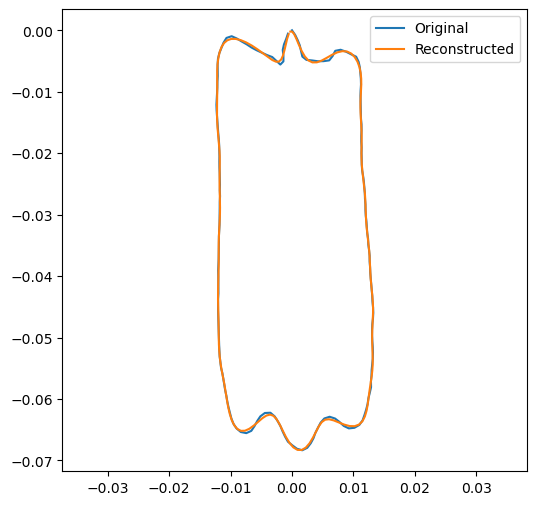

In [18]:
import matplotlib.pyplot as plt


def reconstruct_from_fourier(
    contour,
    n_coeffs=20
):

    z = contour[:, 0] + 1j * contour[:, 1]

    coeffs = np.fft.fft(z)

    compressed = np.zeros_like(coeffs)

    compressed[:n_coeffs] = coeffs[:n_coeffs]
    compressed[-n_coeffs:] = coeffs[-n_coeffs:]

    z_rec = np.fft.ifft(compressed)

    reconstructed = np.column_stack([
        z_rec.real,
        z_rec.imag
    ])

    return reconstructed


sample = df_training.iloc[0]["contour"]

reconstructed = reconstruct_from_fourier(
    sample,
    n_coeffs=20
)

plt.figure(figsize=(6,6))

plt.plot(
    sample[:,0],
    sample[:,1],
    label="Original"
)

plt.plot(
    reconstructed[:,0],
    reconstructed[:,1],
    label="Reconstructed"
)

plt.axis("equal")
plt.legend()
plt.show()

### Baseline Random Forest Model for evaluation of pipeline


## Baseline Model Evaluation

A Random Forest classifier is trained as a baseline model.

The purpose of this step is not necessarily to achieve optimal performance, but to:

- Verify that the generated features contain predictive information.
- Validate the dataset construction pipeline.
- Establish a benchmark for future models.


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       134
           1       0.98      0.96      0.97       133

    accuracy                           0.97       267
   macro avg       0.97      0.97      0.97       267
weighted avg       0.97      0.97      0.97       267

